In [1]:
# ─────────────────────────────────────────────
# [C1] 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas scipy statsmodels matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm   # 내장 데이터(china_smoking)·보조 도구

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다. (시뮬레이션 셀에 적용)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    # 리눅스·Colab에서 한글이 □□로 보이면 아래를 먼저 실행하세요.
    # !apt-get -qq install -y fonts-nanum && rm -rf ~/.cache/matplotlib
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료!")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("scipy :", scipy.__version__)

준비 완료!
numpy : 2.4.6
pandas: 3.0.3
scipy : 1.17.1


In [2]:
# [C2] ── 실습 데이터 로드 — 모두 라이브러리가 제공하는 데이터셋 ──
#   · titanic  (seaborn)                : 생존·성별·등급        → 카이제곱
#   · tips     (seaborn)                : 결제액(우편향)        → Mann-Whitney
#   · penguins (seaborn)                : 종·체중              → Kruskal-Wallis
#   · jtrain   (statsmodels/Rdatasets)  : 같은 기업 87/88 불량률 → Wilcoxon
#   · ResumeNames (statsmodels/Rdatasets): 무작위 현장실험      → A/B형 카이제곱

titanic = sns.load_dataset("titanic")
tips    = sns.load_dataset("tips")

# 체중·종·성별에 결측이 있는 행은 검정에서 쓸 수 없으므로 미리 제거합니다.
penguins = sns.load_dataset("penguins").dropna(subset=["body_mass_g", "species", "sex"])  # 결측(NaN) 제거

# 같은 기업(fcode)의 1987 vs 1988 불량률 — '짝지어진' 두 측정
jtrain = sm.datasets.get_rdataset("jtrain", "wooldridge").data
scrap = (jtrain.pivot_table(index="fcode", columns="year", values="scrap")  # 행=대상, 열=시점으로 재배열 (짝 만들기)
                [[1987, 1988]].dropna())                          # 결측(NaN) 제거
before, after = scrap[1987], scrap[1988]

# 이력서 현장실험 — 그룹(이름 유형) × 결과(면접 연락 여부)
resume = sm.datasets.get_rdataset("ResumeNames", "AER").data

print("titanic :", titanic.shape, "| 컬럼 예:", list(titanic.columns[:6]))
print("tips    :", tips.shape, "| 컬럼 예:", list(tips.columns))
print("penguins:", penguins.shape, "| 종:", penguins["species"].unique().tolist())
print("scrap   :", scrap.shape, f"| 87·88년 모두 기록된 기업 {len(scrap)}곳")
print("resume  :", resume.shape, "| 그룹:", resume["ethnicity"].unique().tolist(),
      "| 결과:", resume["call"].unique().tolist())
print()
print("titanic 미리보기 (생존·성별·등급):")
print(titanic[["survived", "sex", "class", "embarked", "fare"]].head())

titanic : (891, 15) | 컬럼 예: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch']
tips    : (244, 7) | 컬럼 예: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
penguins: (333, 7) | 종: ['Adelie', 'Chinstrap', 'Gentoo']
scrap   : (54, 2) | 87·88년 모두 기록된 기업 54곳
resume  : (4870, 27) | 그룹: ['cauc', 'afam'] | 결과: ['no', 'yes']

titanic 미리보기 (생존·성별·등급):
   survived     sex  class embarked     fare
0         0    male  Third        S   7.2500
1         1  female  First        C  71.2833
2         1  female  Third        S   7.9250
3         1  female  First        S  53.1000
4         0    male  Third        S   8.0500


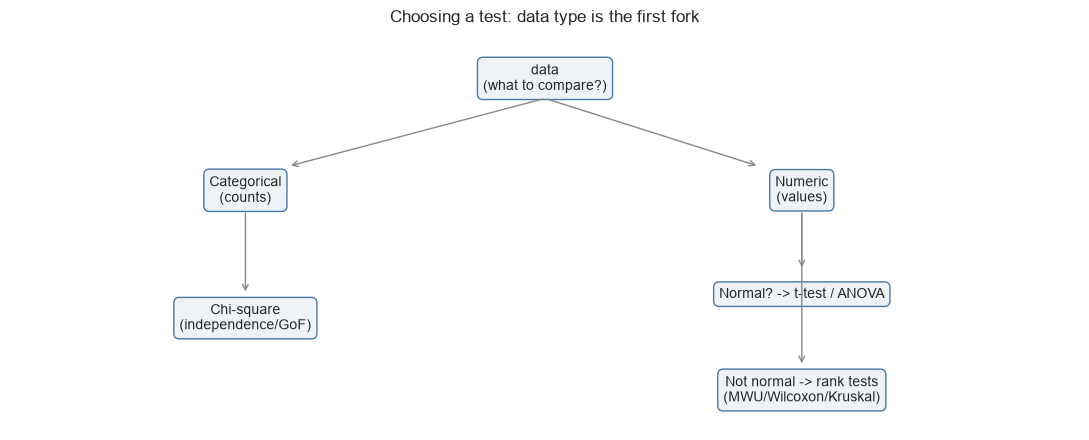

In [3]:
# [C3] [도식] 검정 선택 흐름 — 데이터 타입이 첫 갈림길
fig, ax = plt.subplots(figsize=(11, 4.5))                         # 그래프 하나를 그릴 도화지 준비
ax.axis("off")
boxes = {
    "data\n(what to compare?)": (0.5, 0.88),
    "Categorical\n(counts)":   (0.22, 0.60),
    "Numeric\n(values)":       (0.74, 0.60),
    "Chi-square\n(independence/GoF)": (0.22, 0.28),
    "Normal? -> t-test / ANOVA": (0.74, 0.34),
    "Not normal -> rank tests\n(MWU/Wilcoxon/Kruskal)": (0.74, 0.10),
}
for txt, (x, y) in boxes.items():
    ax.annotate(txt, (x, y), ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.4", fc="#eef3f8", ec="#4a78a8"))
for x0, y0, x1, y1 in [(0.5,0.83,0.26,0.66),(0.5,0.83,0.7,0.66),
                       (0.22,0.55,0.22,0.34),(0.74,0.55,0.74,0.40),(0.74,0.55,0.74,0.16)]:
    ax.annotate("", (x1, y1), (x0, y0), arrowprops=dict(arrowstyle="->", color="#888"))
ax.set_title("Choosing a test: data type is the first fork")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

In [4]:
# [C4] 1) 분할표(교차표) 만들기 — 성별 × 생존
ct = pd.crosstab(titanic["sex"], titanic["survived"])             # 분할표(교차표) — 두 범주의 조합별 개수를 셈
ct.columns = ["사망(0)", "생존(1)"]
print("관측빈도 (성별 × 생존):")
print(ct)
print()

# 2) 카이제곱 독립성 검정
chi2, p, dof, expected = stats.chi2_contingency(ct)               # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
print(f"chi2 = {chi2:.2f},  df = {dof},  p = {p:.2e}")
print()
print("기대빈도 E (독립이라면 기대되는 개수):")
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))

관측빈도 (성별 × 생존):
        사망(0)  생존(1)
sex                 
female     81    233
male      468    109

chi2 = 260.72,  df = 1,  p = 1.20e-58

기대빈도 E (독립이라면 기대되는 개수):
        사망(0)  생존(1)
sex                 
female  193.5  120.5
male    355.5  221.5


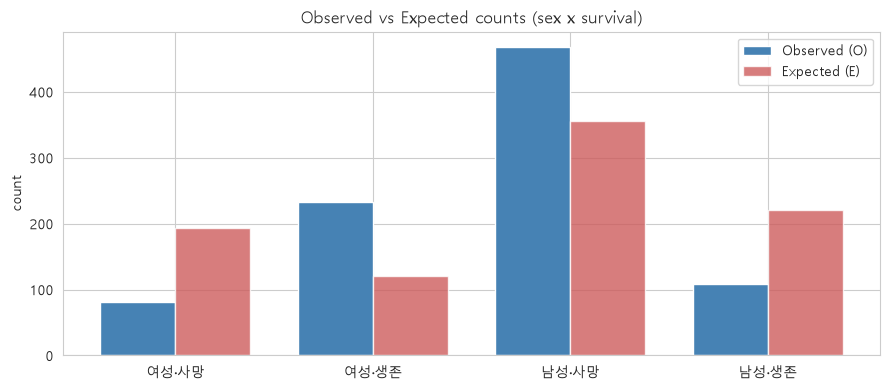

In [5]:
plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

warnings.filterwarnings("ignore")


# [C5] [도식] 관측빈도 vs 기대빈도 — 어긋남이 클수록 연관이 강하다
labels = ["여성·사망", "여성·생존", "남성·사망", "남성·생존"]
obs = ct.values.flatten()
exp = expected.flatten()
x = np.arange(len(labels)); w = 0.38                              # 정수 눈금 배열 생성
fig, ax = plt.subplots(figsize=(9, 4))                            # 그래프 하나를 그릴 도화지 준비
ax.bar(x - w/2, obs, w, label="Observed (O)", color="steelblue")
ax.bar(x + w/2, exp, w, label="Expected (E)", color="indianred", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("count")
ax.set_title("Observed vs Expected counts (sex x survival)"); ax.legend()
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

In [6]:
# [C6] 적합도 검정(goodness-of-fit) — "한 범주의 분포가 기대와 맞나?"
# 예: 탑승 항구(embarked) 분포가 균등(1/3씩)하다고 볼 수 있나?
emb = titanic["embarked"].dropna().value_counts()                 # 결측(NaN) 제거
expected_uniform = [emb.sum() / len(emb)] * len(emb)   # 균등 기대
stat, p_gof = stats.chisquare(f_obs=emb.values, f_exp=expected_uniform)  # 카이제곱 적합도 검정 — 관측이 기대 비율과 맞나
print("항구별 관측 인원:"); print(emb)
print(f"\n적합도 검정: chi2 = {stat:.1f}, p = {p_gof:.2e}")
print("→ p가 매우 작으니 '균등 분포'라는 가정은 기각 — 항구마다 탑승 인원이 크게 다릅니다.")

항구별 관측 인원:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

적합도 검정: chi2 = 625.8, p = 1.28e-136
→ p가 매우 작으니 '균등 분포'라는 가정은 기각 — 항구마다 탑승 인원이 크게 다릅니다.


등급 × 생존: chi2 = 102.9, df = 2, p = 4.55e-23


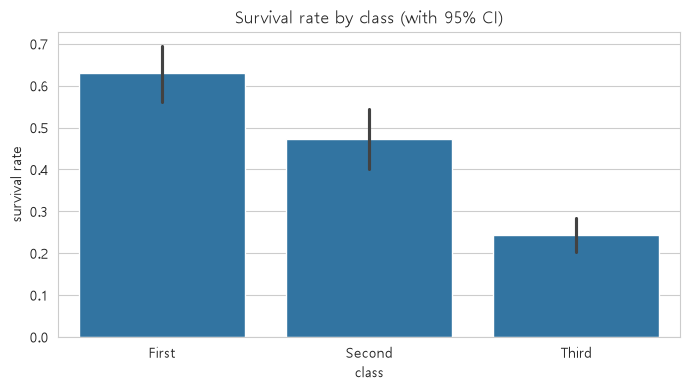

In [7]:
# [C7] 또 다른 독립성 예 — 객실 등급(class) × 생존, seaborn으로 한눈에
ct2 = pd.crosstab(titanic["class"], titanic["survived"])          # 분할표(교차표) — 두 범주의 조합별 개수를 셈
chi2_2, p2, dof2, _ = stats.chi2_contingency(ct2)                 # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
print(f"등급 × 생존: chi2 = {chi2_2:.1f}, df = {dof2}, p = {p2:.2e}")

# 생존율(비율)을 집단 비교로 시각화 — 이해 후 탐색이므로 seaborn 사용
fig, ax = plt.subplots(figsize=(7, 4))                            # 그래프 하나를 그릴 도화지 준비
sns.barplot(data=titanic, x="class", y="survived", ax=ax,         # 집단별 평균 막대 + 신뢰구간 오차선
            order=["First", "Second", "Third"], errorbar=("ci", 95))
ax.set_ylabel("survival rate"); ax.set_title("Survival rate by class (with 95% CI)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

In [8]:
# [C8] 표준화 잔차 — 어느 칸이 연관을 '만드는지' 짚어준다
ct = pd.crosstab(titanic["sex"], titanic["survived"])             # 분할표(교차표) — 두 범주의 조합별 개수를 셈
chi2, p, dof, expected = stats.chi2_contingency(ct)               # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
resid = (ct.values - expected) / np.sqrt(expected)   # (O-E)/sqrt(E)
resid_df = pd.DataFrame(resid, index=ct.index, columns=["사망", "생존"]).round(2)
print("표준화 잔차 (|값| > 2 이면 그 칸이 연관에 크게 기여):")
print(resid_df)
print("\n→ 여성·생존(+)과 남성·사망(+)이 큰 양수, 즉 '기대보다 많다'가 연관의 정체입니다.")

표준화 잔차 (|값| > 2 이면 그 칸이 연관에 크게 기여):
          사망     생존
sex                
female -8.09  10.25
male    5.97  -7.56

→ 여성·생존(+)과 남성·사망(+)이 큰 양수, 즉 '기대보다 많다'가 연관의 정체입니다.


In [9]:
# [C9] Cramér's V 계산 — 연관의 '세기'
def cramers_v(confusion):
    chi2 = stats.chi2_contingency(confusion)[0]                   # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
    n = confusion.values.sum()
    k = min(confusion.shape) - 1
    return np.sqrt(chi2 / (n * k))

v_sex   = cramers_v(pd.crosstab(titanic["sex"],   titanic["survived"]))  # 분할표(교차표) — 두 범주의 조합별 개수를 셈
v_class = cramers_v(pd.crosstab(titanic["class"], titanic["survived"]))  # 분할표(교차표) — 두 범주의 조합별 개수를 셈
print(f"성별 × 생존  Cramér's V = {v_sex:.3f}  (강함)")
print(f"등급 × 생존  Cramér's V = {v_class:.3f}  (중간)")
print("기준(2x2): 0.1 작음 · 0.3 중간 · 0.5 큼")

성별 × 생존  Cramér's V = 0.541  (강함)
등급 × 생존  Cramér's V = 0.340  (중간)
기준(2x2): 0.1 작음 · 0.3 중간 · 0.5 큼


In [10]:
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
import numpy as np

# 데이터 로드
titanic = sns.load_dataset('titanic')

# 1) 분할표(contingency table) 생성
ct = pd.crosstab(titanic['embarked'], titanic['survived'])
print("=== 분할표 (관측빈도) ===")
print(ct)
print()

# 2) 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(ct)

print(f"카이제곱 통계량: {chi2:.4f}")
print(f"자유도(dof): {dof}")
print(f"p-value: {p:.4e}")
print()
print("=== 기대빈도 ===")
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(2))
print()

# Cramér's V 계산 (효과크기)
n = ct.sum().sum()
min_dim = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramér's V: {cramers_v:.4f}")
print()

# 3) 결론
alpha = 0.05
if p < alpha:
    print(f"결론: p={p:.4e} < 0.05 이므로 탑승 항구와 생존 여부는 통계적으로 유의한 관련이 있다 (Cramér's V={cramers_v:.3f})")
else:
    print(f"결론: p={p:.4e} >= 0.05 이므로 탑승 항구와 생존 여부는 통계적으로 유의한 관련이 있다고 보기 어렵다")

=== 분할표 (관측빈도) ===
survived    0    1
embarked          
C          75   93
Q          47   30
S         427  217

카이제곱 통계량: 26.4891
자유도(dof): 2
p-value: 1.7699e-06

=== 기대빈도 ===
survived       0       1
embarked                
C         103.75   64.25
Q          47.55   29.45
S         397.70  246.30

Cramér's V: 0.1726

결론: p=1.7699e-06 < 0.05 이므로 탑승 항구와 생존 여부는 통계적으로 유의한 관련이 있다 (Cramér's V=0.173)


In [11]:
# [C11] titanic으로 조건부확률 직접 계산
p_survive          = titanic["survived"].mean()
p_survive_female   = titanic.loc[titanic["sex"] == "female", "survived"].mean()
p_survive_male     = titanic.loc[titanic["sex"] == "male",   "survived"].mean()
p_female           = (titanic["sex"] == "female").mean()

print(f"P(생존)             = {p_survive:.3f}")
print(f"P(생존 | 여성)      = {p_survive_female:.3f}")
print(f"P(생존 | 남성)      = {p_survive_male:.3f}")
print()
# 베이즈로 방향 뒤집기: P(여성 | 생존) = P(생존|여성) P(여성) / P(생존)
p_female_given_survive = p_survive_female * p_female / p_survive
print(f"P(여성 | 생존)      = {p_female_given_survive:.3f}  (베이즈 정리로 계산)")
# 검산: 직접 세어도 같은지
check = (titanic.loc[titanic["survived"] == 1, "sex"] == "female").mean()
print(f"직접 센 값          = {check:.3f}  ← 일치 확인")

P(생존)             = 0.384
P(생존 | 여성)      = 0.742
P(생존 | 남성)      = 0.189

P(여성 | 생존)      = 0.681  (베이즈 정리로 계산)
직접 센 값          = 0.681  ← 일치 확인


In [12]:
# [C12] 베이즈 정리 — 양성일 때 실제 질병 확률 P(질병 | 양성)
prevalence  = 0.01    # P(질병) 유병률
sensitivity = 0.99    # P(양성 | 질병)
specificity = 0.95    # P(음성 | 정상)  →  P(양성 | 정상) = 1 - 0.95

p_pos_given_disease = sensitivity
p_pos_given_healthy = 1 - specificity
# 전체 양성 확률 P(양성) = 민감도·유병 + 오탐·비유병
p_positive = p_pos_given_disease * prevalence + p_pos_given_healthy * (1 - prevalence)
p_disease_given_pos = p_pos_given_disease * prevalence / p_positive

print(f"P(양성)            = {p_positive:.4f}")
print(f"P(질병 | 양성)     = {p_disease_given_pos:.3f}  ({p_disease_given_pos*100:.1f}%)")
print("→ 양성인데도 실제 질병 확률은 약 17%뿐! 유병률이 낮으면 오탐이 진짜를 압도합니다.")

P(양성)            = 0.0594
P(질병 | 양성)     = 0.167  (16.7%)
→ 양성인데도 실제 질병 확률은 약 17%뿐! 유병률이 낮으면 오탐이 진짜를 압도합니다.


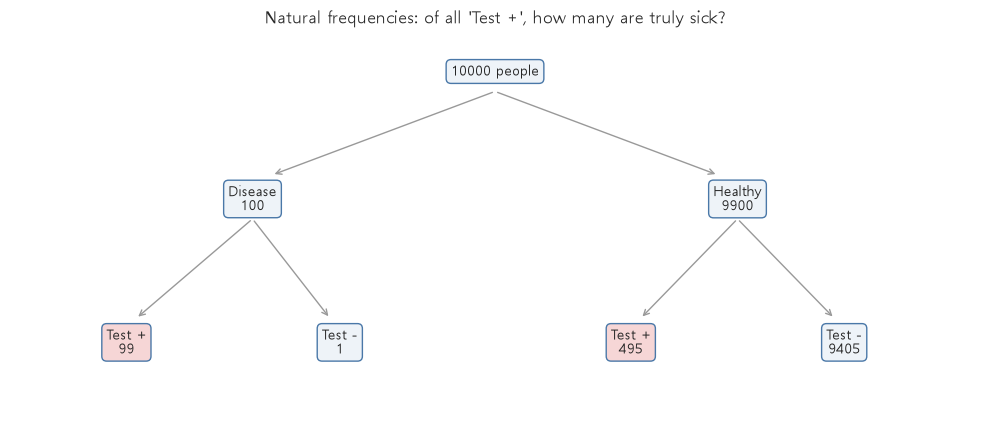

양성 판정 총원 = 594명 중 진짜 질병은 99명 → 16.7%


In [13]:
# [C13] [도식] 자연빈도 나무 — 10,000명으로 베이즈 직관 잡기
N = 10000
prev, sens, spec = 0.01, 0.99, 0.95
disease = int(N * prev); healthy = N - disease        # 질병 100 / 건강 9900
tp = int(disease * sens); fn = disease - tp           # 진양성 99 / 위음성 1
fp = int(healthy * (1 - spec)); tn = healthy - fp     # 위양성 495 / 진음성 9405

fig, ax = plt.subplots(figsize=(10, 4.5)); ax.axis("off")         # 그래프 하나를 그릴 도화지 준비
nodes = {f"{N} people": (0.5, 0.9),
         f"Disease\n{disease}": (0.25, 0.58), f"Healthy\n{healthy}": (0.75, 0.58),
         f"Test +\n{tp}": (0.12, 0.22), f"Test -\n{fn}": (0.34, 0.22),
         f"Test +\n{fp}": (0.64, 0.22), f"Test -\n{tn}": (0.86, 0.22)}
for txt, (x, y) in nodes.items():
    fc = "#f6d6d6" if "Test +" in txt else "#eef3f8"
    ax.annotate(txt, (x, y), ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.35", fc=fc, ec="#4a78a8"))
for x0, y0, x1, y1 in [(0.5,0.85,0.27,0.64),(0.5,0.85,0.73,0.64),
                       (0.25,0.53,0.13,0.28),(0.25,0.53,0.33,0.28),
                       (0.75,0.53,0.65,0.28),(0.75,0.53,0.85,0.28)]:
    ax.annotate("", (x1, y1), (x0, y0), arrowprops=dict(arrowstyle="->", color="#999"))
ax.set_title("Natural frequencies: of all 'Test +', how many are truly sick?")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력
print(f"양성 판정 총원 = {tp+fp}명 중 진짜 질병은 {tp}명 → {tp/(tp+fp):.1%}")

In [14]:
import pandas as pd
import seaborn as sns

# 데이터 로드
titanic = sns.load_dataset('titanic')

# 1) P(생존 | 1등석) — 1등석 승객 중 생존한 비율
first_class = titanic[titanic['pclass'] == 1]
p_survived_given_first = first_class['survived'].mean()

print(f"1등석 승객 수: {len(first_class)}")
print(f"1등석 중 생존자 수: {first_class['survived'].sum()}")
print(f"P(생존 | 1등석) = {p_survived_given_first:.4f}")
print()

# 2) P(1등석 | 생존) — 생존자 중 1등석 비율
survivors = titanic[titanic['survived'] == 1]
p_first_given_survived = (survivors['pclass'] == 1).mean()

print(f"생존자 수: {len(survivors)}")
print(f"생존자 중 1등석 수: {(survivors['pclass'] == 1).sum()}")
print(f"P(1등석 | 생존) = {p_first_given_survived:.4f}")
print()

# 검증: 직접 공식대로도 계산해보기
# P(A|B) = P(A∩B) / P(B)
n = len(titanic)
p_first_and_survived = ((titanic['pclass']==1) & (titanic['survived']==1)).sum() / n
p_first_class = (titanic['pclass']==1).mean()
p_survived = titanic['survived'].mean()

print("=== 공식으로 검증 ===")
print(f"P(1등석 ∩ 생존) = {p_first_and_survived:.4f}")
print(f"P(1등석) = {p_first_class:.4f}")
print(f"P(생존) = {p_survived:.4f}")
print(f"P(생존|1등석) 재계산 = {p_first_and_survived/p_first_class:.4f}")
print(f"P(1등석|생존) 재계산 = {p_first_and_survived/p_survived:.4f}")
print()

# 3) 결론
print("결론: P(생존|1등석)은 '1등석 승객'이라는 좁은 그룹(모집단) 안에서 생존 비율을 보는 것이고,")
print("     P(1등석|생존)은 '생존자'라는 다른 그룹 안에서 1등석 비율을 보는 것이라, 분모(기준 모집단)가 다르기 때문에 값도 다르다.")

1등석 승객 수: 216
1등석 중 생존자 수: 136
P(생존 | 1등석) = 0.6296

생존자 수: 342
생존자 중 1등석 수: 136
P(1등석 | 생존) = 0.3977

=== 공식으로 검증 ===
P(1등석 ∩ 생존) = 0.1526
P(1등석) = 0.2424
P(생존) = 0.3838
P(생존|1등석) 재계산 = 0.6296
P(1등석|생존) 재계산 = 0.3977

결론: P(생존|1등석)은 '1등석 승객'이라는 좁은 그룹(모집단) 안에서 생존 비율을 보는 것이고,
     P(1등석|생존)은 '생존자'라는 다른 그룹 안에서 1등석 비율을 보는 것이라, 분모(기준 모집단)가 다르기 때문에 값도 다르다.


Shapiro-Wilk (정규성): p = 3.32e-10  → p가 작으니 '정규분포 아님'


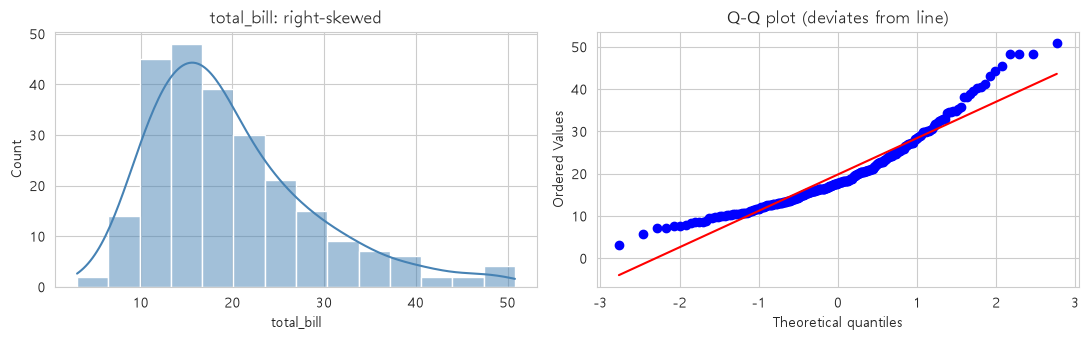

In [15]:
# [C15] 먼저 정규성부터 확인 — tips 결제액은 우편향(비정규)
bill = tips["total_bill"]
sw_stat, sw_p = stats.shapiro(bill)                               # 정규성 검정 — H0: 정규분포를 따른다
print(f"Shapiro-Wilk (정규성): p = {sw_p:.2e}  → p가 작으니 '정규분포 아님'")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))                 # 그림 한 장에 그래프 2개(1행 2열)
sns.histplot(bill, kde=True, ax=axes[0], color="steelblue")       # 히스토그램 — 값이 어디에 몰려 있나
axes[0].set_title("total_bill: right-skewed")
stats.probplot(bill, dist="norm", plot=axes[1])   # Q-Q plot
axes[1].set_title("Q-Q plot (deviates from line)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

In [16]:
# [C16] (1) Mann-Whitney U — 두 독립 집단 (남 vs 여 결제액), t-test와 비교
m = tips.loc[tips["sex"] == "Male",   "total_bill"]
f = tips.loc[tips["sex"] == "Female", "total_bill"]

u_stat, u_p = stats.mannwhitneyu(m, f, alternative="two-sided")   # Mann-Whitney U — 2표본 t-test의 비모수 짝꿍(순위 비교)
t_stat, t_p = stats.ttest_ind(m, f, equal_var=False)              # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
print(f"Mann-Whitney U : U = {u_stat:.0f}, p = {u_p:.4f}")
print(f"(참고) Welch t  : t = {t_stat:.3f}, p = {t_p:.4f}")
print(f"\n중앙값: 남성 {m.median():.2f} vs 여성 {f.median():.2f}")

Mann-Whitney U : U = 8046, p = 0.0214
(참고) Welch t  : t = 2.373, p = 0.0186

중앙값: 남성 18.35 vs 여성 16.40


In [17]:
# [C17] (2) Wilcoxon 부호순위 — 짝지어진 두 측정 (실데이터: 같은 기업의 87 → 88 불량률)
w_stat, w_p = stats.wilcoxon(before, after)                       # Wilcoxon 부호순위 — 대응표본 t-test의 비모수 짝꿍
t_stat, t_p = stats.ttest_rel(before, after)      # 모수 짝꿍(대응표본 t) — D013에서 배운 그 검정

print(f"Wilcoxon 부호순위 : W = {w_stat:.0f}, p = {w_p:.4f}")
print(f"(참고) 대응표본 t  : t = {t_stat:.3f}, p = {t_p:.4f}")
print(f"\n중앙값 변화: {before.median():.2f}% → {after.median():.2f}%"
      f"   (평균 변화 {(after - before).mean():+.2f}%p)")
print(f"차이의 정규성(Shapiro) p = {stats.shapiro(after - before).pvalue:.2e}"  # 정규성 검정 — H0: 정규분포를 따른다
      "  → 정규 가정이 약하므로 순위 기반 검정이 더 안전")
print("→ 같은 대상의 '전-후 차이'에 순위를 매겨 검정합니다(대응표본 t의 비모수판).")

Wilcoxon 부호순위 : W = 329, p = 0.0029
(참고) 대응표본 t  : t = 2.523, p = 0.0147

중앙값 변화: 1.67% → 1.51%   (평균 변화 -0.82%p)
차이의 정규성(Shapiro) p = 2.20e-08  → 정규 가정이 약하므로 순위 기반 검정이 더 안전
→ 같은 대상의 '전-후 차이'에 순위를 매겨 검정합니다(대응표본 t의 비모수판).


In [18]:
# [C18] (3) Kruskal-Wallis — 세 집단 이상 (penguins 종별 체중), ANOVA와 비교
groups = [g["body_mass_g"].values for _, g in penguins.groupby("species")]  # 집단별로 묶어서 계산
h_stat, h_p = stats.kruskal(*groups)                              # Kruskal-Wallis — ANOVA의 비모수 짝꿍
f_stat, f_p = stats.f_oneway(*groups)                             # 일원 ANOVA — F = 집단 간 분산 / 집단 내 분산
print(f"Kruskal-Wallis : H = {h_stat:.1f}, p = {h_p:.2e}")
print(f"(참고) ANOVA   : F = {f_stat:.1f}, p = {f_p:.2e}")
for name, g in penguins.groupby("species"):                       # 집단별로 묶어서 계산
    print(f"  {name:10s} 중앙값 {g['body_mass_g'].median():.0f} g")

Kruskal-Wallis : H = 212.1, p = 8.84e-47
(참고) ANOVA   : F = 341.9, p = 3.74e-81
  Adelie     중앙값 3700 g
  Chinstrap  중앙값 3700 g
  Gentoo     중앙값 5050 g


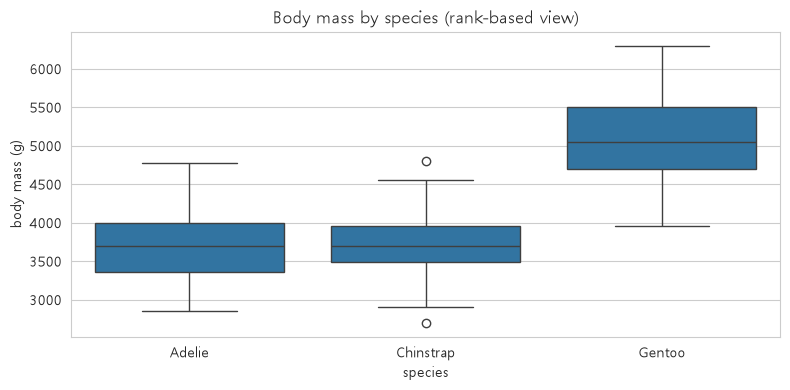

In [19]:
# [C19] [도식] 비모수가 보는 그림 — 분포 전체를 집단별로 (seaborn)
fig, ax = plt.subplots(figsize=(8, 4))                            # 그래프 하나를 그릴 도화지 준비
sns.boxplot(data=penguins, x="species", y="body_mass_g", ax=ax,   # 상자그림 — 중앙값·사분위·이상치를 한눈에
            order=["Adelie", "Chinstrap", "Gentoo"])
ax.set_title("Body mass by species (rank-based view)")
ax.set_ylabel("body mass (g)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

In [20]:
# [C20] 순위(rank)는 이렇게 매겨진다 — 두 집단을 합쳐 등수만 남긴다
A = [12, 15, 22]        # 집단 A
B = [18, 25, 30, 40]    # 집단 B
allv = np.array(A + B)
ranks = stats.rankdata(allv)        # 전체를 합쳐 등수 부여
print("값  :", allv.tolist())
print("순위:", ranks.tolist())
print(f"A의 순위합 = {ranks[:3].sum():.0f},  B의 순위합 = {ranks[3:].sum():.0f}")
print("→ Mann-Whitney U는 이 '순위합'으로 두 집단의 위치 차이를 잽니다. 값 40을 100만으로 바꿔도 순위는 그대로!")

값  : [12, 15, 22, 18, 25, 30, 40]
순위: [1.0, 2.0, 4.0, 3.0, 5.0, 6.0, 7.0]
A의 순위합 = 7,  B의 순위합 = 21
→ Mann-Whitney U는 이 '순위합'으로 두 집단의 위치 차이를 잽니다. 값 40을 100만으로 바꿔도 순위는 그대로!


In [21]:
# [C21] 비모수 효과 크기 — rank-biserial correlation (Mann-Whitney용)
m = tips.loc[tips["sex"] == "Male",   "total_bill"]
f = tips.loc[tips["sex"] == "Female", "total_bill"]
U, p = stats.mannwhitneyu(m, f, alternative="two-sided")          # Mann-Whitney U — 2표본 t-test의 비모수 짝꿍(순위 비교)
rank_biserial = 1 - 2 * U / (len(m) * len(f))   # -1~1, 0이면 차이 없음
print(f"Mann-Whitney U = {U:.0f}, p = {p:.4f}")
print(f"rank-biserial 효과 크기 = {abs(rank_biserial):.3f}  (0 작음 ~ 1 큼)")
print("→ 유의성(p)과 함께 '얼마나 다른가'(효과 크기)를 보고하는 습관은 모수·비모수 공통입니다.")

Mann-Whitney U = 8046, p = 0.0214
rank-biserial 효과 크기 = 0.178  (0 작음 ~ 1 큼)
→ 유의성(p)과 함께 '얼마나 다른가'(효과 크기)를 보고하는 습관은 모수·비모수 공통입니다.


=== 종별 부리 길이 요약 ===
           count       mean       std   min    25%    50%     75%   max
species                                                                
Adelie     151.0  38.791391  2.663405  32.1  36.75  38.80  40.750  46.0
Chinstrap   68.0  48.833824  3.339256  40.9  46.35  49.55  51.075  58.0
Gentoo     123.0  47.504878  3.081857  40.9  45.30  47.30  49.550  59.6

Kruskal-Wallis H = 244.1367
자유도 = 2
p-value = 9.6914e-54

Epsilon-squared (효과크기) = 0.7159

결론: p=9.6914e-54 < 0.05 이므로 종에 따라 부리 길이 분포가 통계적으로 유의하게 다르다 (ε²=0.716)


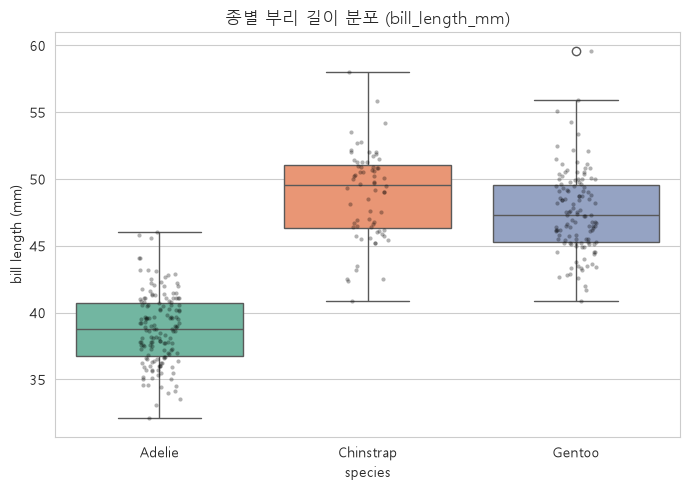

In [22]:
from scipy.stats import kruskal

# 데이터 로드
penguins = sns.load_dataset('penguins')
penguins = penguins.dropna(subset=['bill_length_mm', 'species'])  # 결측치 제거

# 종별로 데이터 나누기
species_groups = [group['bill_length_mm'].values 
                  for name, group in penguins.groupby('species')]

print("=== 종별 부리 길이 요약 ===")
print(penguins.groupby('species')['bill_length_mm'].describe())
print()

# 1) Kruskal-Wallis 검정
H, p = kruskal(*species_groups)

# 자유도 = 그룹수 - 1
dof = penguins['species'].nunique() - 1

print(f"Kruskal-Wallis H = {H:.4f}")
print(f"자유도 = {dof}")
print(f"p-value = {p:.4e}")
print()

# 효과크기 epsilon-squared
N = len(penguins)
epsilon_sq = H / (N - 1)
print(f"Epsilon-squared (효과크기) = {epsilon_sq:.4f}")
print()

alpha = 0.05
if p < alpha:
    print(f"결론: p={p:.4e} < 0.05 이므로 종에 따라 부리 길이 분포가 통계적으로 유의하게 다르다 (ε²={epsilon_sq:.3f})")
else:
    print(f"결론: p={p:.4e} >= 0.05 이므로 종에 따른 부리 길이 차이가 유의하다고 보기 어렵다")

# 2) 박스플롯으로 시각 확인
plt.figure(figsize=(7, 5))
sns.boxplot(data=penguins, x='species', y='bill_length_mm', hue='species',
            palette='Set2', legend=False)
sns.stripplot(data=penguins, x='species', y='bill_length_mm',
              color='black', alpha=0.3, size=3, jitter=True)
plt.title('종별 부리 길이 분포 (bill_length_mm)')
plt.xlabel('species')
plt.ylabel('bill length (mm)')
plt.tight_layout()
plt.show()

In [23]:
# [C23] A/B 테스트형 분석 — 그룹 × 결과(연락 여부) 2x2 분할표, 카이제곱 검정
#   실데이터: ResumeNames (동일 이력서에 이름만 무작위 배정한 현장실험)
ab = pd.crosstab(resume["ethnicity"], resume["call"])          # 행=그룹, 열=연락 여부
ab = ab[["yes", "no"]]                                          # 보기 좋게 열 순서 정리
ab.index = ["그룹 A (afam형 이름)", "그룹 B (cauc형 이름)"]
ab.columns = ["연락옴", "연락없음"]
print("A/B 분할표 (실제 현장실험 결과):")
print(ab)

chi2_ab, p_ab, dof_ab, exp_ab = stats.chi2_contingency(ab)        # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
rate_a = ab.iloc[0, 0] / ab.iloc[0].sum()
rate_b = ab.iloc[1, 0] / ab.iloc[1].sum()

# 효과 크기 두 가지: Cramér's V(연관의 세기)와 오즈비(OR)
V_ab = np.sqrt(chi2_ab / (ab.values.sum() * (min(ab.shape) - 1)))
odds_ab = (ab.iloc[1, 0] * ab.iloc[0, 1]) / (ab.iloc[1, 1] * ab.iloc[0, 0])

print(f"\n연락률: A = {rate_a:.2%},  B = {rate_b:.2%}   (절대 차이 {rate_b - rate_a:+.2%}p)")
print(f"카이제곱: chi2 = {chi2_ab:.2f}, df = {dof_ab}, p = {p_ab:.2e}")
print(f"효과 크기: Cramér's V = {V_ab:.3f}   오즈비 OR = {odds_ab:.2f}")
print(f"각 칸 최소 기대빈도 = {exp_ab.min():.1f}  (5 이상이면 카이제곱 근사 OK)")

A/B 분할표 (실제 현장실험 결과):
                 연락옴  연락없음
그룹 A (afam형 이름)  157  2278
그룹 B (cauc형 이름)  235  2200

연락률: A = 6.45%,  B = 9.65%   (절대 차이 +3.20%p)
카이제곱: chi2 = 16.45, df = 1, p = 5.00e-05
효과 크기: Cramér's V = 0.058   오즈비 OR = 1.55
각 칸 최소 기대빈도 = 196.0  (5 이상이면 카이제곱 근사 OK)


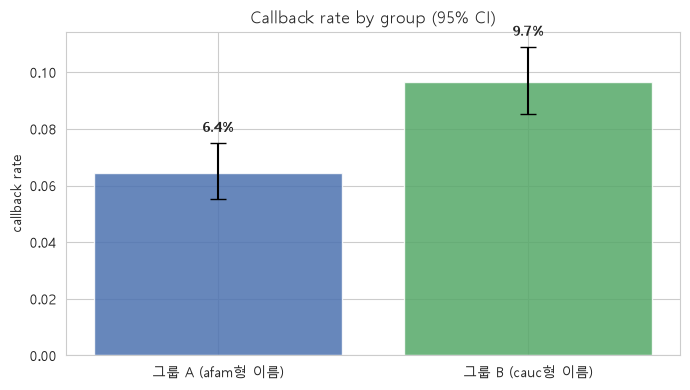

          group   rate     lo     hi    n
그룹 A (afam형 이름) 0.0645 0.0554 0.0749 2435
그룹 B (cauc형 이름) 0.0965 0.0854 0.1089 2435


In [24]:
# [C24] [도식] 두 그룹의 연락률 비교 + 95% 신뢰구간
from statsmodels.stats.proportion import proportion_confint

rows = []
for label in ab.index:
    succ, n = int(ab.loc[label, "연락옴"]), int(ab.loc[label].sum())
    lo, hi = proportion_confint(succ, n, method="wilson")     # 비율의 95% 신뢰구간
    rows.append({"group": label, "rate": succ / n, "lo": lo, "hi": hi, "n": n})
res = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))                            # 그래프 하나를 그릴 도화지 준비
ax.bar(res["group"], res["rate"], color=["#4C72B0", "#55A868"], alpha=0.85)
ax.errorbar(res["group"], res["rate"],                            # 오차막대(신뢰구간) 표시
            yerr=[res["rate"] - res["lo"], res["hi"] - res["rate"]],
            fmt="none", ecolor="black", capsize=6)
for i, r in res.iterrows():
    ax.text(i, r["hi"] + 0.004, f"{r['rate']:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("callback rate"); ax.set_title("Callback rate by group (95% CI)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력
print(res.round(4).to_string(index=False))

In [25]:
# [C25] 전환율 차이별로 '유의'해지는 데 필요한 대략의 표본 (감 잡기용 모의실험)
# 기준 비율은 위 실험에서 관측된 전체 연락률(약 8%)을 씁니다.
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
base = float((resume["call"] == "yes").mean())
print(f"기준 비율(관측 전체 연락률) = {base:.3f}\n")

for lift in [0.01, 0.02, 0.03, 0.05]:
    found = None
    for n in [200, 500, 1000, 2500, 5000, 20000]:
        hits = 0
        for _ in range(120):
            a = np.random.binomial(n, base)                       # 이항 난수 — n번 시도 중 성공 횟수
            b = np.random.binomial(n, base + lift)                # 이항 난수 — n번 시도 중 성공 횟수
            if stats.chi2_contingency([[a, n - a], [b, n - b]])[1] < 0.05:  # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
                hits += 1
        if hits / 120 >= 0.8:            # 약 80% 검정력
            found = n
            break
    msg = f"그룹당 약 {found:,}명 이상 필요" if found else "20,000명으로도 80% 검정력 미달"
    print(f"  +{lift*100:.0f}%p 차이를 80% 확률로 잡으려면 : {msg}")

기준 비율(관측 전체 연락률) = 0.080

  +1%p 차이를 80% 확률로 잡으려면 : 그룹당 약 20,000명 이상 필요
  +2%p 차이를 80% 확률로 잡으려면 : 그룹당 약 5,000명 이상 필요
  +3%p 차이를 80% 확률로 잡으려면 : 그룹당 약 2,500명 이상 필요
  +5%p 차이를 80% 확률로 잡으려면 : 그룹당 약 1,000명 이상 필요


In [26]:
# 1) quality × call 분할표
qc = pd.crosstab(resume["quality"], resume["call"])
qc = qc[["yes", "no"]]
qc.index = ["그룹 H (high quality)", "그룹 L (low quality)"]
qc.columns = ["연락옴", "연락없음"]

print("품질 분할표 (실제 현장실험 결과):")
print(qc)
print()

# 카이제곱 독립성 검정
chi2_qc, p_qc, dof_qc, exp_qc = stats.chi2_contingency(qc)

rate_h = qc.iloc[0, 0] / qc.iloc[0].sum()
rate_l = qc.iloc[1, 0] / qc.iloc[1].sum()

# 효과크기: Cramér's V, 오즈비
V_qc = np.sqrt(chi2_qc / (qc.values.sum() * (min(qc.shape) - 1)))
odds_qc = (qc.iloc[0, 0] * qc.iloc[1, 1]) / (qc.iloc[1, 0] * qc.iloc[0, 1])

print(f"연락률: H = {rate_h:.2%},  L = {rate_l:.2%}   (절대 차이 {rate_h - rate_l:+.2%}p)")
print(f"카이제곱: chi2 = {chi2_qc:.2f}, df = {dof_qc}, p = {p_qc:.2e}")
print(f"효과 크기: Cramér's V = {V_qc:.3f}   오즈비 OR = {odds_qc:.2f}")
print(f"각 칸 최소 기대빈도 = {exp_qc.min():.1f}  (5 이상이면 카이제곱 근사 OK)")

품질 분할표 (실제 현장실험 결과):
                     연락옴  연락없음
그룹 H (high quality)  214  2232
그룹 L (low quality)   178  2246

연락률: H = 8.75%,  L = 7.34%   (절대 차이 +1.41%p)
카이제곱: chi2 = 3.06, df = 1, p = 8.01e-02
효과 크기: Cramér's V = 0.025   오즈비 OR = 1.21
각 칸 최소 기대빈도 = 195.1  (5 이상이면 카이제곱 근사 OK)


1. p값은 0.0801로 유의하지 않음 즉 그룹 H와 L은 독립이 아니라고 할 근거가 부족하다
2. 절대차이는 그룹 H가 1.41%p더 높다
3. Cramér's V=0.025로 연관성은 매우 약하고, 오즈비도 1.21로 크지 않다. p값이 유의하지 않은 |것과 일관된 결과이며, 품질에 따른 콜백률 차이는 통계적으로도, 효과크기 면에서도 뚜렷하지 않다.

## 심화 종합 프로젝트

In [27]:
# [C27] [1] titanic — 객실 등급 × 생존 (카이제곱 독립성)
ct = pd.crosstab(titanic["class"], titanic["survived"])           # 분할표(교차표) — 두 범주의 조합별 개수를 셈
chi2, p, dof, _ = stats.chi2_contingency(ct)                      # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
print("[1] 등급 × 생존")
print(ct)
print(f"   chi2 = {chi2:.1f}, df = {dof}, p = {p:.2e}  → 등급과 생존은 관련 있음\n")

[1] 등급 × 생존
survived    0    1
class             
First      80  136
Second     97   87
Third     372  119
   chi2 = 102.9, df = 2, p = 4.55e-23  → 등급과 생존은 관련 있음



In [28]:
# [C28] [2] china_smoking — 흡연 × 폐암 (지역별 카운트를 합산해 2x2 구성)
cs = sm.datasets.china_smoking.load_pandas().data
table = np.array([[cs["smoking_yes_cancer_yes"].sum(), cs["smoking_yes_cancer_no"].sum()],
                  [cs["smoking_no_cancer_yes"].sum(),  cs["smoking_no_cancer_no"].sum()]])
ct_smoke = pd.DataFrame(table, index=["흡연", "비흡연"], columns=["폐암", "정상"])
chi2_s, p_s, dof_s, _ = stats.chi2_contingency(ct_smoke)          # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
# 오즈비(odds ratio)로 연관 강도까지
odds = (table[0,0]*table[1,1]) / (table[0,1]*table[1,0])
print("[2] 흡연 × 폐암 (전 지역 합산)")
print(ct_smoke)
print(f"   chi2 = {chi2_s:.1f}, df = {dof_s}, p = {p_s:.2e},  오즈비 = {odds:.2f}")
print("   → 흡연과 폐암은 강하게 연관(오즈비가 1보다 훨씬 큼)\n")

[2] 흡연 × 폐암 (전 지역 합산)
       폐암    정상
흡연   2930  2359
비흡연  1151  1979
   chi2 = 272.3, df = 1, p = 3.50e-61,  오즈비 = 2.14
   → 흡연과 폐암은 강하게 연관(오즈비가 1보다 훨씬 큼)



In [29]:
# [C29] [3] titanic — 요금(fare)은 우편향 → 등급별 비교는 Kruskal-Wallis
print("[3] 요금(fare) 정규성 점검:", f"Shapiro p = {stats.shapiro(titanic['fare'].dropna()).pvalue:.2e} (비정규)")  # 정규성 검정 — H0: 정규분포를 따른다
fare_groups = [g["fare"].dropna().values for _, g in titanic.groupby("class")]  # 결측(NaN) 제거
H, p_h = stats.kruskal(*fare_groups)                              # Kruskal-Wallis — ANOVA의 비모수 짝꿍
print(f"   Kruskal-Wallis: H = {H:.1f}, p = {p_h:.2e}  → 등급별 요금 분포가 다름")
for name, g in titanic.groupby("class"):                          # 집단별로 묶어서 계산
    print(f"   {name:7s} 요금 중앙값 {g['fare'].median():.1f}")

[3] 요금(fare) 정규성 점검: Shapiro p = 1.08e-43 (비정규)
   Kruskal-Wallis: H = 438.0, p = 7.59e-96  → 등급별 요금 분포가 다름
   First   요금 중앙값 60.3
   Second  요금 중앙값 14.2
   Third   요금 중앙값 8.1


In [30]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats

# 데이터 로드 및 결측치 제거
penguins = sns.load_dataset('penguins')
penguins = penguins.dropna(subset=['sex', 'species'])

# 분할표 생성 (행=species, 열=sex)
ct = pd.crosstab(penguins['species'], penguins['sex'])
print("=== 종 × 성별 분할표 (관측빈도) ===")
print(ct)
print()

# 카이제곱 독립성 검정
chi2, p, dof, expected = stats.chi2_contingency(ct)

print(f"카이제곱: chi2 = {chi2:.4f}, df = {dof}, p = {p:.4e}")
print()
print("=== 기대빈도 ===")
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(2))
print()
print(f"각 칸 최소 기대빈도 = {expected.min():.1f}  (5 이상이면 카이제곱 근사 OK)")
print()

# 효과크기 (Cramér's V)
n = ct.values.sum()
min_dim = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramér's V = {cramers_v:.4f}")
print()

# 종별 성비 확인 (비율로)
print("=== 종별 성비(비율) ===")
print(pd.crosstab(penguins['species'], penguins['sex'], normalize='index').round(3))
print()

# 결론
alpha = 0.05
if p < alpha:
    print(f"결론: p={p:.4e} < 0.05 이므로 종에 따라 성비가 통계적으로 유의하게 다르다 (Cramér's V={cramers_v:.3f})")
else:
    print(f"결론: p={p:.4e} >= 0.05 이므로 종에 따라 성비가 다르다고 볼 근거가 부족하다 (Cramér's V={cramers_v:.3f})")

=== 종 × 성별 분할표 (관측빈도) ===
sex        Female  Male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61

카이제곱: chi2 = 0.0486, df = 2, p = 9.7599e-01

=== 기대빈도 ===
sex        Female   Male
species                 
Adelie      72.34  73.66
Chinstrap   33.69  34.31
Gentoo      58.96  60.04

각 칸 최소 기대빈도 = 33.7  (5 이상이면 카이제곱 근사 OK)

Cramér's V = 0.0121

=== 종별 성비(비율) ===
sex        Female   Male
species                 
Adelie      0.500  0.500
Chinstrap   0.500  0.500
Gentoo      0.487  0.513

결론: p=9.7599e-01 >= 0.05 이므로 종에 따라 성비가 다르다고 볼 근거가 부족하다 (Cramér's V=0.012)
